In [1]:
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
PATH_DATA <- "~/SysBioMed-PLAs/data/datasets/gated_vaccine_processed.rds"
OUT_DIR <- "../../results/sample_qc/vaccine"

sample_col <- "sample"
celltype_col <- "lineage"
pla_col <- "pla_status"

positive_val <- "PLA"
negative_val <- "platelet-free"

max_ci_width <- 0.30
min_platelet_free <- 20

dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

In [3]:
dataset <- readRDS(PATH_DATA)
meta <- dataset@meta.data
meta <- meta %>%
  mutate(
    cell_id = rownames(dataset@meta.data),
    sample_id = .data[[sample_col]],
    celltype_id = .data[[celltype_col]],
    pla_status_id = .data[[pla_col]]
  )

In [4]:
colnames(meta)

[1] "orig.ident"          "nCount_RNA"          "nFeature_RNA"       
 [4] "nCount_ADT"          "nFeature_ADT"        "lane"               
 [7] "donor"               "time"                "celltype.l1"        
[10] "celltype.l2"         "celltype.l3"         "Phase"              
[13] "Batch"               "sample"              "percent.mt"         
[16] "percent.ribo"        "percent.hb"          "mt_outlier_all"     
[19] "is_outlier_RNA"      "is_outlier_protein"  "is_outlier"         
[22] "RNA_snn_res.0.8"     "seurat_clusters"     "RNA_snn_res.0.25"   
[25] "RNA.weight"          "ADT.weight"          "leiden_0.8_totalVI" 
[28] "leiden_0.25_totalVI" "lineage"             "pla_status"         
[31] "celltype_clean"      "cell_id"             "sample_id"          
[34] "celltype_id"         "pla_status_id"

In [5]:
wilson_ci <- function(x, n, conf_level = 0.95) {
  z <- qnorm(1 - (1 - conf_level) / 2)
  p <- x / n
  
  denom <- 1 + z^2 / n
  center <- (p + z^2 / (2 * n)) / denom
  half_width <- (z * sqrt((p * (1 - p) / n) + (z^2 / (4 * n^2)))) / denom
  
  lower <- pmax(0, center - half_width)
  upper <- pmin(1, center + half_width)
  
  data.frame(
    ci_lower = lower,
    ci_upper = upper,
    ci_width = upper - lower
  )
}

In [6]:
summary_table <- meta %>%
  filter(!is.na(pla_status_id)) %>%
  group_by(sample_id, celltype_id) %>%
  summarise(
    n_cells = n(),
    n_PLA = sum(pla_status_id == positive_val, na.rm = TRUE),
    n_platelet_free = sum(pla_status_id == negative_val, na.rm = TRUE),
    freq_PLA = n_PLA / n_cells,
    median_nCount_RNA = median(nCount_RNA, na.rm = TRUE),
    median_nCount_ADT = median(nCount_ADT, na.rm = TRUE),
    median_percent_mt = median(percent.mt, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(freq_PLA))

ci_df <- wilson_ci(
  x = summary_table$n_PLA,
  n = summary_table$n_cells
)

summary_table <- bind_cols(summary_table, ci_df)

neg_threshold <- summary_table %>%
  filter(n_platelet_free > 0) %>%
  summarise(threshold = quantile(n_platelet_free, probs = 0.10, na.rm = TRUE)) %>%
  pull(threshold)

neg_threshold <- as.numeric(max(neg_threshold, 20))

summary_table <- summary_table %>%
  mutate(
    enough_precision = ci_width <= max_ci_width,
    enough_negative_control = n_platelet_free >= neg_threshold,
    usable_celltype_sample = enough_precision & enough_negative_control
  ) %>%
  rowwise() %>%
  ungroup()

write.csv(
  summary_table,
  file.path(OUT_DIR, "01_sample_celltype_summary.csv"),
  row.names = FALSE
)


[1] "P1_0" "P1_7" "P2_0" "P3_7" "P6_2" "P5_0" "P8_0" "P7_7" "P6_7" "P6_0"
[11] "P3_0" "P7_2" "P8_7" "P7_0" "P5_2" "P5_7" "P3_2" "P8_2" "P4_0" "P1_2"
[21] "P4_2" "P2_2" "P2_7" "P4_7"

[1] 0.001885063 0.810937589

[1] 167

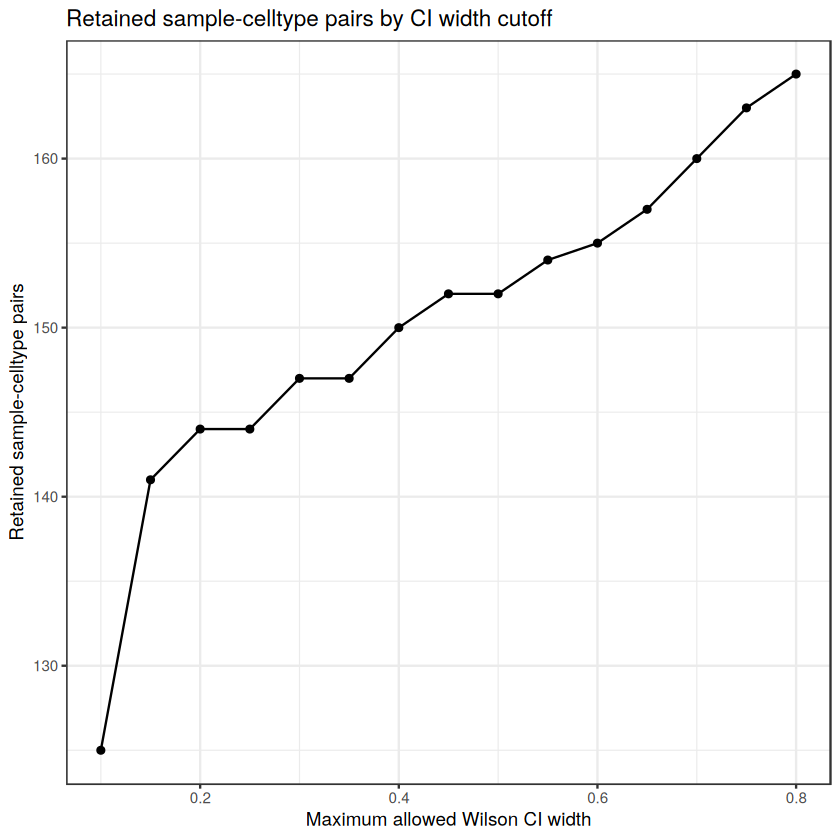

In [7]:
unique(summary_table$sample_id)
range(summary_table$ci_width, na.rm = TRUE)
nrow(summary_table)


ci_grid <- seq(0.1, 0.8, by = 0.05)

retention_df <- lapply(ci_grid, function(cutoff) {
  tmp <- summary_table %>%
    mutate(usable = ci_width <= cutoff)
  
  data.frame(
    max_ci_width = cutoff,
    retained_pairs = sum(tmp$usable, na.rm = TRUE),
    retained_cells = sum(tmp$n_cells[tmp$usable], na.rm = TRUE),
    retained_PLA = sum(tmp$n_PLA[tmp$usable], na.rm = TRUE)
  )
}) %>%
  bind_rows()

p_retention_current <- ggplot(retention_df, aes(x = max_ci_width, y = retained_pairs)) +
  geom_line() +
  geom_point() +
  theme_bw() +
  labs(
    title = "Retained sample-celltype pairs by CI width cutoff",
    x = "Maximum allowed Wilson CI width",
    y = "Retained sample-celltype pairs"
  )

print(p_retention_current)

In [8]:
usable_pairs <- summary_table %>%
  filter(usable_celltype_sample) %>%
  select(sample_id, celltype_id, n_cells, n_PLA, n_platelet_free, freq_PLA, ci_lower, ci_upper, ci_width, enough_negative_control)

excluded_pairs <- summary_table %>%
  filter(!usable_celltype_sample) %>%
  select(sample_id, celltype_id, n_cells, n_PLA, n_platelet_free, freq_PLA, ci_lower, ci_upper, ci_width, enough_negative_control)

write.csv(
  usable_pairs,
  file.path(OUT_DIR, "02_usable_sample_celltype_pairs.csv"),
  row.names = FALSE
)

write.csv(
  excluded_pairs,
  file.path(OUT_DIR, "03_excluded_sample_celltype_pairs.csv"),
  row.names = FALSE
)

In [ ]:
summary_table <- summary_table %>%
  mutate(
    sample_id = as.character(sample_id),
    celltype_id = as.character(celltype_id)
  )

sample_order <- summary_table %>%
  group_by(sample_id) %>%
  summarise(total_PLA = sum(n_PLA, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total_PLA)) %>%
  pull(sample_id)

celltype_order <- summary_table %>%
  group_by(celltype_id) %>%
  summarise(total_PLA = sum(n_PLA, na.rm = TRUE), .groups = "drop") %>%
  arrange(total_PLA) %>%
  pull(celltype_id)

plot_df <- summary_table %>%
  complete(
    sample_id = sample_order,
    celltype_id = celltype_order,
    fill = list(
      n_cells = NA_integer_,
      n_PLA = NA_integer_,
      n_platelet_free = NA_integer_,  
      freq_PLA = NA_real_,
      ci_width = NA_real_,
      enough_precision = FALSE,
      enough_negative_control = FALSE,
      usable_celltype_sample = FALSE
    )
  ) %>%
  mutate(
    sample_id = factor(sample_id, levels = sample_order),
    celltype_id = factor(celltype_id, levels = celltype_order),
    freq_PLA_plot = ifelse(usable_celltype_sample, freq_PLA, NA_real_),
    label_fraction = case_when(
      is.na(n_cells) ~ "NA",
      !enough_precision & !enough_negative_control ~ "unstable\nlow neg",
      !enough_precision ~ "unstable",
      !enough_negative_control ~ "low neg",
      usable_celltype_sample ~ paste0(round(freq_PLA * 100, 1), "%"),
      TRUE ~ ""
    )
  )

In [10]:
head(dataset)

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,lane,donor,time,celltype.l1,celltype.l2,⋯,RNA_snn_res.0.8,seurat_clusters,RNA_snn_res.0.25,RNA.weight,ADT.weight,leiden_0.8_totalVI,leiden_0.25_totalVI,lineage,pla_status,celltype_clean
,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>
L1_AAACCCAAGAAACTCA,SeuratProject,10823,2915,7430,221,L1,P2,7,Mono,CD14 Mono,⋯,1,3,3,0.1853620,0.8146380,5,1,Monocytes,PLA,Classical-Monocytes
L1_AAACCCAAGACATACA,SeuratProject,5864,1617,5949,211,L1,P1,7,CD4 T,CD4 TCM,⋯,0,0,0,0.1494304,0.8505696,2,0,CD4 T cells,platelet-free,T-cells-CD4
L1_AAACCCACAACTGGTT,SeuratProject,5067,1381,6547,217,L1,P4,2,CD8 T,CD8 Naive,⋯,8,6,6,0.4036141,0.5963859,6,4,CD8 T cells,platelet-free,T-cells-CD8
L1_AAACCCACACGTACTA,SeuratProject,4786,1890,3508,207,L1,P3,7,NK,NK,⋯,12,2,2,0.4298022,0.5701978,3,2,NK cells,platelet-free,Late-NK-cells
L1_AAACCCACAGCATACT,SeuratProject,6505,1621,6318,219,L1,P4,7,CD8 T,CD8 Naive,⋯,8,6,6,0.1872517,0.8127483,6,4,CD8 T cells,platelet-free,T-cells-CD8
L1_AAACCCACATCAGTCA,SeuratProject,4332,1633,5195,213,L1,P3,2,CD8 T,CD8 TEM,⋯,9,4,4,0.2947371,0.7052629,4,3,CD8 T cells,platelet-free,T-cells-CD8
L1_AAACCCACATCGGTTA,SeuratProject,9333,2672,7507,223,L1,P1,7,Mono,CD16 Mono,⋯,15,8,8,0.8400041,0.1599959,0,1,Monocytes,PLA,Classical-Monocytes
L1_AAACCCACATGGATCT,SeuratProject,3589,1122,8138,226,L1,P4,2,B,B intermediate,⋯,13,5,5,0.2033271,0.7966729,7,5,B cells,platelet-free,Total-memory-B-cells
L1_AAACCCAGTGGAACAC,SeuratProject,3251,1375,2858,205,L1,P1,2,NK,NK,⋯,12,2,2,0.4062224,0.5937776,3,2,NK cells,platelet-free,Late-NK-cells


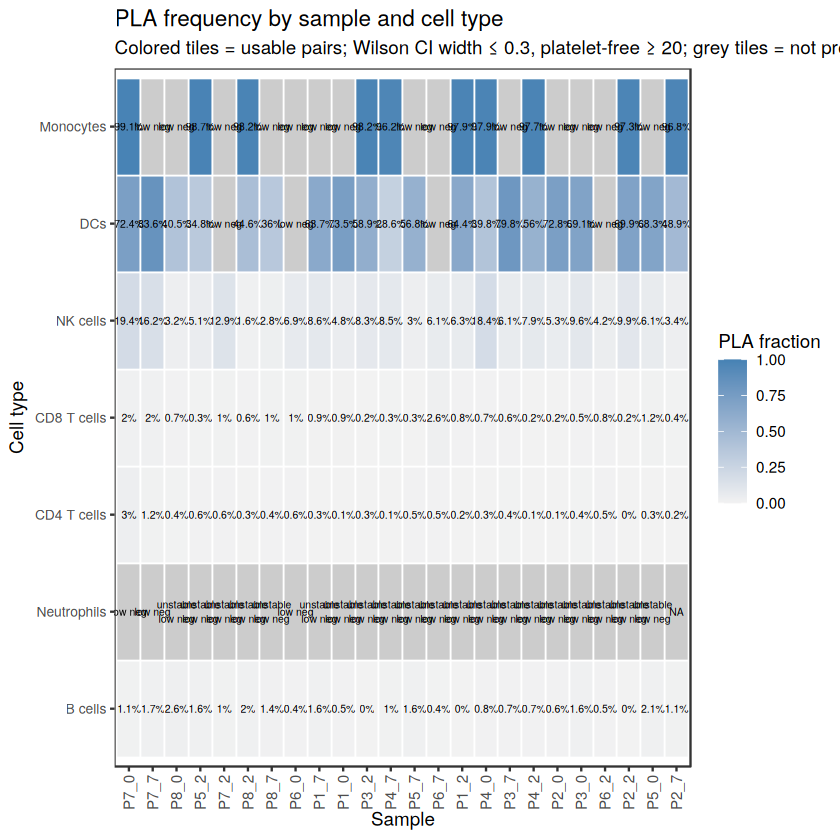

In [11]:
plot_width <- max(10, length(sample_order) * 0.35)
plot_height <- max(7, length(celltype_order) * 0.28)

p_heat <- ggplot(plot_df, aes(x = sample_id, y = celltype_id, fill = freq_PLA_plot)) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = label_fraction), size = 2.1) +
  scale_fill_gradient(
    low = "grey95",
    high = "steelblue",
    limits = c(0, 1),
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.text.y = element_text(size = 8)
  ) +
  labs(
    title = "PLA frequency by sample and cell type",
    subtitle = paste0(
      "Colored tiles = usable pairs; Wilson CI width ≤ ", max_ci_width,
      ", platelet-free ≥ ", neg_threshold,
      "; grey tiles = not present or not usable"
    ),
    x = "Sample",
    y = "Cell type",
    fill = "PLA fraction"
  )

print(p_heat)

ggsave(
  file.path(OUT_DIR, "04_PLA_frequency_by_sample_celltype_filtered.png"),
  p_heat,
  width = plot_width,
  height = plot_height,
  dpi = 300
)

In [12]:
qc_overview <- summary_table %>%
  summarise(
    total_pairs = n(),
    usable_pairs = sum(usable_celltype_sample, na.rm = TRUE),
    unstable_pairs = sum(!enough_precision, na.rm = TRUE),
    low_neg_pairs = sum(!enough_negative_control, na.rm = TRUE),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    total_cells = sum(n_cells, na.rm = TRUE),
    total_PLA = sum(n_PLA, na.rm = TRUE),
    retained_cell_fraction = retained_cells / total_cells,
    retained_PLA_fraction = retained_PLA / total_PLA
  )

print(qc_overview)
write.csv(qc_overview, file.path(OUT_DIR, "05_qc_filter_overview.csv"), row.names = FALSE)

# A tibble: 1 × 10
  total_pairs usable_pairs unstable_pairs low_neg_pairs retained_cells
        <int>        <int>          <int>         <int>          <int>
1         167          126             20            41         108471
# ℹ 5 more variables: retained_PLA <int>, total_cells <int>, total_PLA <int>,
#   retained_cell_fraction <dbl>, retained_PLA_fraction <dbl>


In [13]:
usable_by_celltype <- summary_table %>%
  group_by(celltype_id) %>%
  summarise(
    total_pairs = n(),
    usable_pairs = sum(usable_celltype_sample, na.rm = TRUE),
    usable_samples = n_distinct(sample_id[usable_celltype_sample]),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    mean_freq_PLA_usable = mean(freq_PLA[usable_celltype_sample], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(retained_PLA))

print(usable_by_celltype, n = Inf)
write.csv(usable_by_celltype, file.path(OUT_DIR, "06_usable_by_celltype.csv"), row.names = FALSE)

# A tibble: 7 × 7
  celltype_id total_pairs usable_pairs usable_samples retained_cells
  <chr>             <int>        <int>          <int>          <int>
1 Monocytes            24           10             10          14732
2 DCs                  24           20             20           4894
3 NK cells             24           24             24          17823
4 CD8 T cells          24           24             24          21758
5 CD4 T cells          24           24             24          39105
6 B cells              24           24             24          10159
7 Neutrophils          23            0              0              0
# ℹ 2 more variables: retained_PLA <int>, mean_freq_PLA_usable <dbl>


In [14]:
usable_by_sample <- summary_table %>%
  group_by(sample_id) %>%
  summarise(
    total_celltypes = n(),
    usable_celltypes = sum(usable_celltype_sample, na.rm = TRUE),
    retained_cells = sum(n_cells[usable_celltype_sample], na.rm = TRUE),
    retained_PLA = sum(n_PLA[usable_celltype_sample], na.rm = TRUE),
    mean_freq_PLA_usable = mean(freq_PLA[usable_celltype_sample], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(retained_PLA))

print(usable_by_sample, n = Inf)
write.csv(usable_by_sample, file.path(OUT_DIR, "07_usable_by_sample.csv"), row.names = FALSE)

# A tibble: 24 × 6
   sample_id total_celltypes usable_celltypes retained_cells retained_PLA
   <chr>               <int>            <int>          <int>        <int>
 1 P7_0                    7                6           6840         3298
 2 P5_2                    7                6           4983         2694
 3 P8_2                    7                6           7894         1969
 4 P3_2                    7                6           4702         1574
 5 P4_7                    7                6           5258         1530
 6 P1_2                    7                6           5482         1289
 7 P4_0                    7                6           4593         1267
 8 P4_2                    7                6           5299         1082
 9 P2_2                    7                6           5005          970
10 P2_7                    6                6           4666          879
11 P7_7                    7                5           4254          347
12 P1_0            

In [ ]:
usable_pairs <- summary_table %>%
  filter(usable_celltype_sample) %>%
  select(sample_id, celltype_id)

meta_usable <- meta %>%
  semi_join(usable_pairs, by = c("sample_id", "celltype_id"))

usable_cells <- meta_usable$cell_id

dataset_usable <- subset(dataset, cells = usable_cells)

saveRDS(
  dataset_usable,
  file.path(OUT_DIR, "dataset_usable_sample_celltype_pairs.rds")
)

saveRDS(
  summary_table,
  file.path(OUT_DIR, "sample_celltype_frequency_QC_table.rds")
)